##### 1. TimeEmbedding

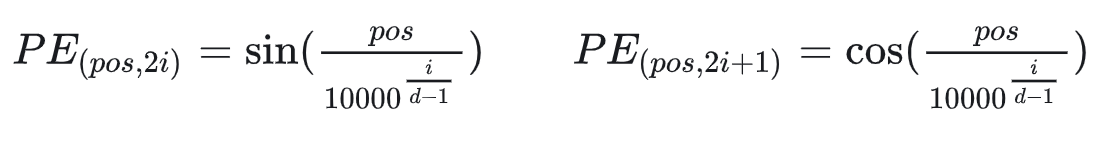

Q1: 为什么要把时间 t 变成一个很长的向量，(time_channels == model_channels * 4)?

A1: 直接把一个具体的“数值时间”喂给网络，标量提供的信息太少，很难理解数值间的大小关系，我们需要把 t 升维成一个高维向量，让网络有丰富的信号可以学习。


Q2: 怎么把 t 变成高维向量？

A2: 假设 t 为 5，我们准备用六种快慢长度不同的波来处理当前的标量 t，[sin(5 * 0.1), sin(5 * 0.2), sin(5 * 0.3)] 代表是 t 这个标量对应的时间嵌入向量的前一半，后一半用余弦计算，然后拼在一起。


Q3: 这么做的好处是什么？

A3: 相似的 t 会得到相似但不相同的编码，不同维度的变化不同，有些维度能区分大步，有些维度能区分小步，而且这种编码是确定的，平滑的。


Q4: 如何直观的理解呢？

A4: 假设我传达现在是“19815秒”，如果只给一个标量数字，很难立刻感知到它是早晨还是下午，也很难立刻算出它和“19820秒”差了多少。现实中，我们表示时间的方式其实也是类似的“向量”（表盘）。一个时钟有秒针、分针、时针。

- 秒针（高频）：转得飞快。如果两段相近的时间（比如 t = 5 和 t = 9），秒针的位置截然不同，区分极小的步长。
- 时针（低频）：转得极慢。一整天只转两圈。定位大局位置，比如当前是模型加噪的早期还是晚期。
- 在神经网络里，把标量 t 变成高维向量，就相当于造了一个有成百上千根指针的时钟，前几个维度就是疯狂旋转的“秒针”，最后几个维度就是几万步才转一圈的“时针”。网络看到这个高维向量，能瞬间同时感知到“当前的大阶段”和“当前的小细节”。


Q5: 为什么需要一半 sin，一半 cos？

A5: 只用 sin 波，有一个致命缺陷就是 sin(0) = 0，sin($\pi$) = 0。两个完全不同的时间点，在这根指针上却输出了相同的数值，网络会感到困惑。(cos($\theta$), sin($\theta$)) 决定了圆上的一个唯一坐标点。所以把 sin 和 cos 拼在一起。


Q6: 假设直接把数位熵的值改为向量不可以吗（t = 19180, [1, 9, 1, 8, 0]）？

A6: 这样的话假设时间标量从 099 变成了 100，在现实中，时间只前进了微小的一小步（1 个单位）。但如果用数位向量表示，它从 [0, 9, 9] 突变成了 [1, 0, 0]。向量里的每一个维度都发生了剧烈的跳变，神经网络是非常害怕这种“不连续突变”的。它在计算梯度时，希望输入的变化是平滑可导的，即微小的输入变化对应微小的特征变化。如果是数位向量 [0, 9, 9] 和 [1, 0, 0]，它们在多维空间里的欧氏距离非常远，网络很难通过简单的加减乘除，立刻明白它们其实只差了 1 步。

一句话总结就是：微小的输入变化对应微小的特征变化，不同的频率感受不同的阶段，变化不要跳变，并且最好的不同时间的每个时间嵌入向量位置都不相同。

#### 2. ResidualBlock

残差块的结构

- 1. GroupNorm
- 2. SiLU
- 3. Conv2d
- 4. SiLU + TimeEmbedding
- 5. GroupNorm
- 6. SiLU
- 7. Dropout
- 8. Conv2d

Q1: 为什么不使用最常见的 BatchNorm 搭配 ReLU，反而使用 GroupNorm 和 SilU？

A1: BatchNorm 的原理是对一个 batch 内的每个通道计算均值和方差，假设现在的 batch 构造为 [32, 3, 32, 32]，那么对于其中一个通道，均值就是他这个通道上的 32 * 32 * 32 个数字的均值和方差，每个通道独立做的话因为都归一化到了均值为 0 方差为 1，可能本来通道间分布的对比度被影响，GroupNorm 在这背景下使用更好，多个通道联手计算一个均值额方差，效果相对较好？SiLU(x) = x * Sigmoid(x)，在预测微小噪声的扩散模型中，ReLU 模式的一刀切可能会导致细微梯度丢失。而 SiLU 是一把精密手术刀，它在 0 附近有平滑曲线，保留了微弱的负数信号，提供平滑的梯度，相对更加符合生成模型。另外，因为 TimeEmbedding 存在一半的负数，ReLU 会直接损害时间嵌入的效果。


Q2: 时间嵌入为什么加在两次卷积之间？

A2: 假设加在最前面，特征图 x 刚进来，什么空间信息都没提取，直接把时间加给它，第一层卷积会被这种强烈的全局信号干扰，可能连基本的图像边缘都提取不准。假设加在最后面，两层卷积都已经干完活，再把时间加进去，时间信号就只变成了一个无足轻重的“全局偏置”，完全没有参与到“图像特征的重组计算”中去。

#### 3. Attention

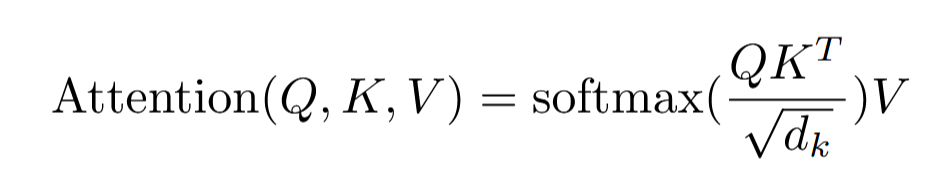

Q1: 使用 attention 模块的原因是什么？

A1: 卷积模块的感受野有限，需要叠很多层，信息才能关联起来，attention 能在同一瞬间，直接和图上的所有其他像素进行交互，计算它们的关联度。

具体的操作是，对于传进来的图片，从 [b, c, h, w] 转换成 [b, c, len] 形状，可以被看作把一张特征图转换成了一个“句子”，然后调整成 [b, len, c] 的维度，线性变换形状为 [b, len, num_heads * d_k * 3]，然后 reshape 成形状 [b, len, num_heads, d_k * 3] 后劈成三份分给 q, k, v，这时候的 q, k, v 的每个的形状是 [b, len, num_heads, d_k]，然后计算 $\sqrt{d_k}$。注意力得分是爱因斯坦基来计算的，对于每个批次 b 的每个头，拿第 i 个长度为 d 的向量去和当前头的第 j 个向量做点积，batch 内每个头算出来一个 [len, len] 大小的矩阵，也就是公式的 $QK^T$，然后按照公式除以 $\sqrt{d_k}$。

Q2: 除以 $\sqrt{d_k}$ 的原因是什么？

A2: 假设 Q 和 K 里面的每一个数字，都是独立的随机变量，均值为 0，方差为 1。那么它们的内积 $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$：均值依然是 0。方差会变成 d_k，方差变大，意味着分数分布极其分散，极端大值频出。除以方差的算术平方根 $\sqrt{d_k}$ 把方差拉回到 1。

假设 q 和 k 是两个长度为 d_k 的向量。里面的每一个元素 $q_i$ 和 $k_i$ 都是互相独立的随机变量。根据假设，它们的均值是 0，方差是 1：$E[q_i] = 0 \quad E[k_i] = 0$，$Var(q_i) = 1 \quad Var(k_i) = 1$ 因为 $q_i$ 和 $k_i$ 互相独立，$E[q_i k_i] = E[q_i] \times E[k_i] = 0 \times 0 = 0$。因为 $E[q_i] = 0$，所以 $Var(q_i) = E[q_i^2] - 0 = 1$，得出 $E[q_i^2] = 1$。同理 $E[k_i^2] = 1$。

$Var(q_i k_i) = E[(q_i k_i)^2] - (E[q_i k_i])^2$，$Var(q_i k_i) = E[q_i^2] \times E[k_i^2] - 0 = 1 \times 1 = 1$ 每一对 $q_i$ 和 $k_i$ 相乘后，均值依然是 0，方差依然是 1。

$S = \sum_{i=1}^{d_k} q_i k_i$。$E[S] = \sum_{i=1}^{d_k} E[q_i k_i] = \sum_{i=1}^{d_k} 0 = 0$，$Var(S) = \sum_{i=1}^{d_k} Var(q_i k_i) = \sum_{i=1}^{d_k} 1 = d_k$。

$Var(C \times S) = C^2 \times Var(S)$，$C^2 = \frac{1}{d_k}$，$C = \frac{1}{\sqrt{d_k}}$

然后 softmax 之后，拿这个得分去乘上 v 向量，即得到 attention 值，先重塑把多头拼接，然后投影回原始的通道数加上原始输入返回即可。

#### 4. DownBlock and UpBlock && DownSample, MidSample and, UpSample

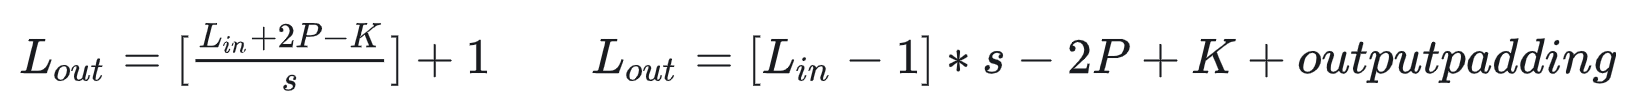
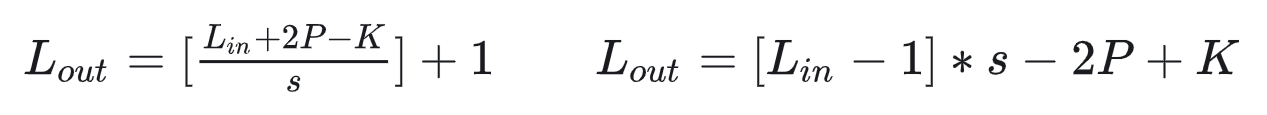
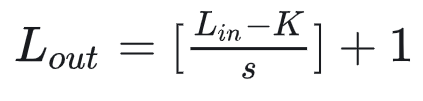

下采样块和上采样块是残差块和注意力块的堆叠，前者负责提取局部细节，但是因为其是感受野有限，后面的 Attention 模块负责全局视野，但是 Attention 模块的计算量与显存占用和像素点的平方成正比，所以加上了开关调节。

工程细节是残差块本身不改变输出的大小，然后下上采样的参数配置 [kernel_size, stride, padding] 分别为 [3, 2, 1], [4, 2, 1]，带入数值可以发现只要输入的图片大小为偶数，执行完下采样的卷积和上采样的反卷积后天然尺寸匹配（放弃使用了原始的 U-net 里面的不 padding 然后 crop 的复杂做法），中间块本身就是残差块叠加注意力块再叠加残差块，没有什么额外的操作。

可以发现不管是残差块还是注意力块，为了更好的堆叠大部分的演化过程就是输入大小等于输出大小。

#### 5. DDPMUNet

Q1: DDPM U-Net 类的核心作用和宏观架构是怎样的？

A1: DDPM U-Net 对应扩散模型论文中的核心去噪网络 $\epsilon_\theta(x_t, t)$。它的任务是接收加噪图像 $x_t$ 和时间步 t，预测出被注入的纯高斯噪声矩阵。架构上，它是一个带有时间条件注入的动态 U 型网络，结合了局部感知的 ResBlock 与全局感知的 AttentionBlock，并通过 channel_mults 列表参数化地动态生成网络深度，彻底摒弃了硬编码层数的做法。

Q2: 为什么在 \_\_init\_\_ 中设计了 channels_stack 列表，并且右侧 UpBlock 的输入通道强制设为 cur_channels * 2？

A2: 因为网络深度是动态设定的，右侧的上采样（Up）模块在建立时，无法预知左侧对应层传来的特征图通道数。在构建左侧下采样模块时，维护一个 channels_stack 记录每一层的通道厚度（压栈）。构建右侧模块时，通过 pop 倒序查账确保参数维度严格对齐。强制设为 cur_channels * 2 是为了给 forward 阶段的拼接预留物理空间。左侧传来的快照（厚度 C）与右侧当前放大的特征（厚度 C）通过 torch.cat((s, x), dim=1) 拼接，厚度瞬间翻倍为 2C，这一预判避免了全连接和卷积计算时的张量形状报错。

Q3: 在 forward 传播中，为什么要使用列表 h = [x] 以及 append/pop 操作？

A3: 列表 h 在物理逻辑上充当了一个后进先出（LIFO）的栈（Stack），用于管理跳跃连接（Skip Connection）。在下采样（Down）阶段，每次经过残差块提取特征后，调用 h.append(x) 将当前特征图压入栈顶。栈中越晚压入的特征图，尺寸越小。在上采样（Up）阶段，每次放大特征后调用 s = h.pop() 弹出栈顶特征。利用栈的 LIFO 特性，最后压入栈的最小尺寸快照会最先被弹出，与当前上采样第一层所需的空间维度分毫不差。这种设计彻底解耦了网络深度与变量名，无论配置多少层，都能自动保证维度完美对齐。

Q4: 为什么在遍历 block 时，要使用 isinstance 函数进行条件判断？

A4: isinstance 是 Python 内置函数，用于动态判断实例类型，左右两侧的 ModuleList 中混杂了 ResBlock 和 Sample 块（如步长为 2 的卷积）。只有经过残差块充分打磨的高质量特征图，才有资格被保存下来传递给解码器。代码通过判断 if isinstance(down_block, DownSample)，规定如果模块仅负责缩小尺寸，则只改变形状，不执行 h.append(x) 压栈操作。右半边同理，以此避免未经充分提取的过渡态特征污染跳跃连接。

Q5: 为什么要将时间嵌入（Time Embedding）的维度强制设为 model_channels * 4？

A5: 图像是一个包含海量像素的高维信息载体，而时间步 t 最初只是一个标量。为了防止关键的时间信号在庞大的图像特征中被稀释和淹没，必须将其特征维度强行放大 4 倍（例如基础通道 128，时间通道则为 512）。这确保了时间向量具备足够的“信息容量”和“存在感”，从而强势引导深层网络中每一个 ResBlock 执行对应时间步的去噪动作。

Q6: 整个 DDPM U-Net forward 函数中，数据的完整流转过程是怎样的？

A6: 
- 1. 入场：图像 x 经过初始卷积增厚，时间 t 转化为高维 Embedding。
- 2. 下沉 (Down)：数据逐层穿过残差块，每打磨一次就留下一份高维快照（入栈 h），随后经过 DownSample 尺寸减半、通道加深。
- 3. 谷底 (Middle)：在尺寸最小处，启动全局注意力机制，计算像素空间拓扑关联。
- 4. 上浮 (Up)：图像经过 UpSample 尺寸翻倍，同时从栈 h 中弹出同级别的历史快照，在通道维度缝合（cat），送入残差块融合。
- 5. 输出：经过最终的 GroupNorm 和 SiLU，用 $3 \times 3$ 卷积将特征图压平成 3 通道的纯噪声预测结果返回。

#### 6. Origin Paper

latent variable: 潜变量指的是逐步增加噪声的中间状态，无法直接观测的变量，这些变量和可观测数据之间存在概率关系。

nonequilibrium thermodynamics: 前向扩散过程被类比为热力学中的扩散：一小滴墨水滴入水中，会逐渐扩散直至分布均匀（熵最大，即纯噪声状态）。对应到数据，是原始图像到不断添加高斯噪声到完全随机噪声的过程。

weighted variational bound: 加权变分下界，因为我们需要一个指标来给 AI 生成的图片的效果来打分，即假设生成的是人脸，有多少的概率当前生成的图片是人脸，也就是算真实的数据分布，但是这个对于 AI 来讲太难了，于是把这个分割成了若干步骤，每步加上一点噪声，算均方误差把刚刚的那一点杂质找出来。

denoising score matching: 去噪得分匹配， 我们训练 U-Net，其实就是在打造一个指南针。AI 看不到最终的完美图片长啥样，它只学一件事：在当前这团乱七八糟的像素里，我该往哪个方向调整一点点，能让它显得少一点噪点。

Langevin dynamics: 如果一个粒子在确定的梯度引导下移动，同时不断受到标准高斯噪声的随机撞击，只要时间足够长，这个粒子在空间中出现的概率分布，刚好严格等于目标分布。而不是收敛到一个“最优解”上，否则 运行 10000 次模型，会得到 10000 张一模一样的图片。这在生成式 AI 里是一个巨大的灾难，被称为模式坍塌（Mode Collapse）。

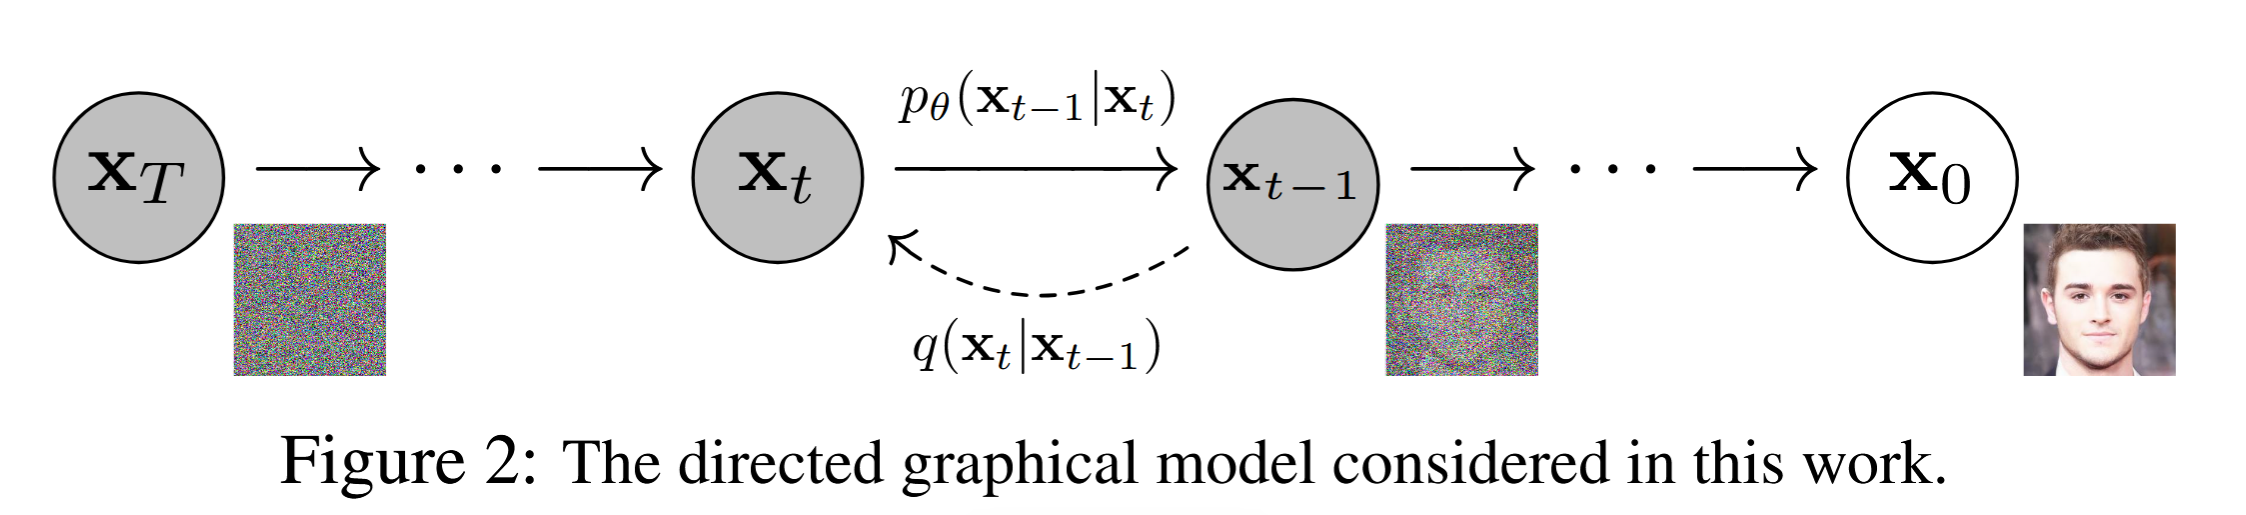